In [1]:
import sys
import os

import sys


if 'google.colab' in sys.modules:
    !wget https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/utils.py
    !mkdir -p notebooks
    !mv utils.py notebooks
    !mkdir output


--2026-04-16 08:53:51--  https://raw.githubusercontent.com/rickiepark/Generative_Deep_Learning_2nd_Edition/main/notebooks/utils.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 771 [text/plain]
Saving to: ‘utils.py’

utils.py            100%[===================>]     771  --.-KB/s    in 0s      

2026-04-16 08:53:51 (37.2 MB/s) - ‘utils.py’ saved [771/771]



In [2]:
import numpy as np

import tensorflow as tf
from tensorflow.keras import datasets, layers, models, optimizers, callbacks

from notebooks.utils import display

In [3]:
# Set image height and width to 16x16 pixels
IMAGE_SIZE = 16

# Divide each pixel into 4 discrete intensity levels
PIXEL_LEVELS = 4

# Set number of convolution filters in each layer
N_FILTERS = 128

# Define number of residual blocks in PixelCNN model
RESIDUAL_BLOCKS = 5

# Set batch size for training iterations
BATCH_SIZE = 128

# Set number of full passes over the training dataset
EPOCHS = 150

In [4]:
# Load Fashion-MNIST dataset from Keras
# x_train contains training images
# Labels are ignored using underscore variables

(x_train, _), (_, _) = datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# function for image preprocessing
def preprocess(imgs_int):
    # add channel dimension to make shape compatible with CNN
    imgs_int = np.expand_dims(imgs_int, -1)

    # resize images to fixed size required by model
    imgs_int = tf.image.resize(imgs_int, (IMAGE_SIZE, IMAGE_SIZE)).numpy()

    # convert pixel values into discrete levels
    imgs_int = (imgs_int / (256 / PIXEL_LEVELS)).astype(int)

    # convert integer image to float format for model input
    imgs = imgs_int.astype("float32")

    # normalize pixel values into range 0 to 1
    imgs = imgs / PIXEL_LEVELS

    # return processed float images and integer encoded images
    return imgs, imgs_int


# apply preprocessing to training images
input_data, output_data = preprocess(x_train)

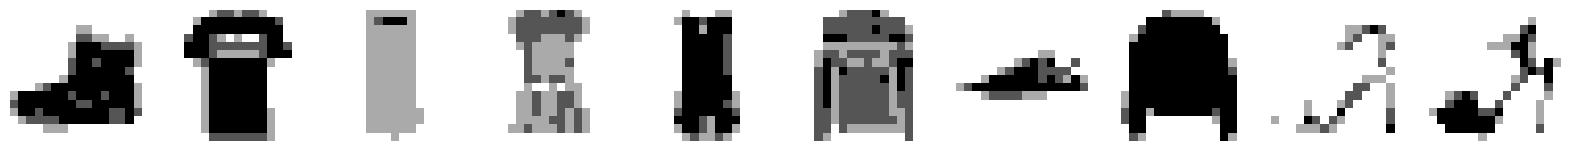

In [6]:
# display sample images from training set
display(input_data)

In [7]:
# PixelCNN layer using masked convolution
# This layer prevents access to future pixels during training
class MaskedConv2D(layers.Layer):
    # initialize layer with mask type and convolution settings
    def __init__(self, mask_type, **kwargs):
        super(MaskedConv2D, self).__init__()

        # store mask type A or B
        self.mask_type = mask_type

        # create standard 2D convolution layer
        self.conv = layers.Conv2D(**kwargs)

    # build layer and create mask
    def build(self, input_shape):
        # build underlying convolution layer
        self.conv.build(input_shape)

        # get kernel shape of convolution filter
        kernel_shape = self.conv.kernel.get_shape()

        # create zero mask with same shape as kernel
        self.mask = np.zeros(shape=kernel_shape)

        # mask upper half of kernel to block future pixels
        self.mask[: kernel_shape[0] // 2, ...] = 1.0

        # mask left half of center row
        self.mask[kernel_shape[0] // 2, : kernel_shape[1] // 2, ...] = 1.0

        # for mask type B allow center pixel
        if self.mask_type == "B":
            self.mask[kernel_shape[0] // 2, kernel_shape[1] // 2, ...] = 1.0

    # apply mask during forward pass
    def call(self, inputs):
        # apply mask to convolution kernel
        self.conv.kernel.assign(self.conv.kernel * self.mask)

        # run convolution on masked kernel
        return self.conv(inputs)

    # return layer configuration
    def get_config(self):
        cfg = super().get_config()
        return cfg

In [8]:
# Residual block used in PixelCNN to improve gradient flow
class ResidualBlock(layers.Layer):

    # initialize block with number of filters
    def __init__(self, filters, **kwargs):
        super(ResidualBlock, self).__init__(**kwargs)

        # 1x1 convolution to reduce number of channels
        self.conv1 = layers.Conv2D(
            filters=filters // 2, kernel_size=1, activation="relu"
        )

        # masked convolution to preserve autoregressive property
        self.pixel_conv = MaskedConv2D(
            mask_type="B",
            filters=filters // 2,
            kernel_size=3,
            activation="relu",
            padding="same",
        )

        # 1x1 convolution to restore original number of channels
        self.conv2 = layers.Conv2D(
            filters=filters, kernel_size=1, activation="relu"
        )

    # forward pass through residual block
    def call(self, inputs):
        # pass input through first convolution
        x = self.conv1(inputs)

        # apply masked convolution
        x = self.pixel_conv(x)

        # pass through second convolution
        x = self.conv2(x)

        # add input to output for residual connection
        return layers.add([inputs, x])

    # return configuration of layer
    def get_config(self):
        cfg = super().get_config()
        return cfg

inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1))
x = MaskedConv2D(
    mask_type="A",
    filters=N_FILTERS,
    kernel_size=7,
    activation="relu",
    padding="same",
)(inputs)

for _ in range(RESIDUAL_BLOCKS):
    x = ResidualBlock(filters=N_FILTERS)(x)

for _ in range(2):
    x = MaskedConv2D(
        mask_type="B",
        filters=N_FILTERS,
        kernel_size=1,
        strides=1,
        activation="relu",
        padding="valid",
    )(x)

out = layers.Conv2D(
    filters=PIXEL_LEVELS,
    kernel_size=1,
    strides=1,
    activation="softmax",
    padding="valid",
)(x)

pixel_cnn = models.Model(inputs, out)
pixel_cnn.summary()                                                                    

This block is giving error so i fix this block and rewrite whole block

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models


# The first layer is the PixelCNN layer with masking
class MaskedConv2D(layers.Layer):
    def __init__(self, mask_type, **kwargs):
        super(MaskedConv2D, self).__init__()
        self.mask_type = mask_type
        self.conv = layers.Conv2D(**kwargs)

    def build(self, input_shape):
        self.conv.build(input_shape)

        # FIX 1: use stable shape API
        kernel_shape = self.conv.kernel.shape.as_list()

        # FIX 2: correct dtype + safe numpy mask
        self.mask = np.zeros(kernel_shape, dtype=np.float32)

        kh, kw, cin, cout = kernel_shape

        # build autoregressive mask
        self.mask[: kh // 2, :, :, :] = 1.0
        self.mask[kh // 2, : kw // 2, :, :] = 1.0

        if self.mask_type == "B":
            self.mask[kh // 2, kw // 2, :, :] = 1.0

    def call(self, inputs):
        # FIX 3: avoid repeated destructive assignment
        masked_kernel = self.conv.kernel * self.mask
        self.conv.kernel.assign(masked_kernel)

        return self.conv(inputs)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"mask_type": self.mask_type})
        return cfg


class ResidualBlock(layers.Layer):
    def __init__(self, filters, **kwargs):
        super(ResidualBlock, self).__init__(**kwargs)

        self.conv1 = layers.Conv2D(
            filters=filters // 2,
            kernel_size=1,
            activation="relu",
            padding="same"
        )

        self.pixel_conv = MaskedConv2D(
            mask_type="B",
            filters=filters // 2,
            kernel_size=3,
            activation="relu",
            padding="same"
        )

        self.conv2 = layers.Conv2D(
            filters=filters,
            kernel_size=1,
            activation="relu",
            padding="same"
        )

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.pixel_conv(x)
        x = self.conv2(x)
        return layers.add([inputs, x])


# ================= MODEL =================

inputs = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 1))

x = MaskedConv2D(
    mask_type="A",
    filters=N_FILTERS,
    kernel_size=7,
    activation="relu",
    padding="same"
)(inputs)

for _ in range(RESIDUAL_BLOCKS):
    x = ResidualBlock(filters=N_FILTERS)(x)

for _ in range(2):
    x = MaskedConv2D(
        mask_type="B",
        filters=N_FILTERS,
        kernel_size=1,
        strides=1,
        activation="relu",
        padding="same"   # FIX 4
    )(x)

out = layers.Conv2D(
    filters=PIXEL_LEVELS,
    kernel_size=1,
    strides=1,
    activation="softmax",
    padding="same"   # FIX 5
)(x)

pixel_cnn = models.Model(inputs, out)
pixel_cnn.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16, 16, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ masked_conv2d (MaskedConv2D)    │ (None, 16, 16, 128)    │         6,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block (ResidualBlock)  │ (None, 16, 16, 128)    │        53,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_1                │ (None, 16, 16, 128)    │        53,504 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_2                │ (None, 16, 16, 128)    │        53,504 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_3                │ (None, 16, 16, 128)    │        53,504 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_block_4                │ (None, 16, 16, 128)    │        53,504 │
│ (ResidualBlock)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ masked_conv2d_6 (MaskedConv2D)  │ (None, 16, 16, 128)    │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ masked_conv2d_7 (MaskedConv2D)  │ (None, 16, 16, 128)    │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 16, 16, 4)      │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,460 (1.17 MB)

 Trainable params: 307,460 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
adam = optimizers.Adam(learning_rate=0.0005)
pixel_cnn.compile(optimizer=adam, loss="sparse_categorical_crossentropy")

In [11]:
tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


class ImageGenerator(callbacks.Callback):
    def __init__(self, num_img):
        self.num_img = num_img

    def sample_from(self, probs, temperature):  # <2>
        probs = probs ** (1 / temperature)
        probs = probs / np.sum(probs)
        return np.random.choice(len(probs), p=probs)

    def generate(self, temperature):
        generated_images = np.zeros(
            shape=(self.num_img,) + (pixel_cnn.input_shape)[1:]
        )
        batch, rows, cols, channels = generated_images.shape

        for row in range(rows):
            for col in range(cols):
                for channel in range(channels):
                    probs = self.model.predict(generated_images, verbose=0)[
                        :, row, col, :
                    ]
                    generated_images[:, row, col, channel] = [
                        self.sample_from(x, temperature) for x in probs
                    ]
                    generated_images[:, row, col, channel] /= PIXEL_LEVELS

        return generated_images

    def on_epoch_end(self, epoch, logs=None):
        if epoch % 10 == 0: #
            generated_images = self.generate(temperature=1.0)
            display(
                generated_images,
                save_to="./output/generated_img_%03d.png" % (epoch),
            )


img_generator_callback = ImageGenerator(num_img=10)

It defines a Keras callback that uses a trained PixelCNN model to autoregressively generate images pixel-by-pixel at the end of training epochs, sampling from predicted probability distributions (with temperature control) and saving the generated samples for visual monitoring of model progress.


     def sample_from(self, probs, temperature):
       
        probs = probs ** (1 / temperature)
        
        robs = probs / np.sum(probs)
        return np.random.choice(len(probs), p=probs)


It randomly samples a class from predicted probabilities, controlled by temperature to make outputs more or less random.It turns model predictions into a random choice instead of picking the highest value.

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.6332
Saved to ./output/generated_img_000.png


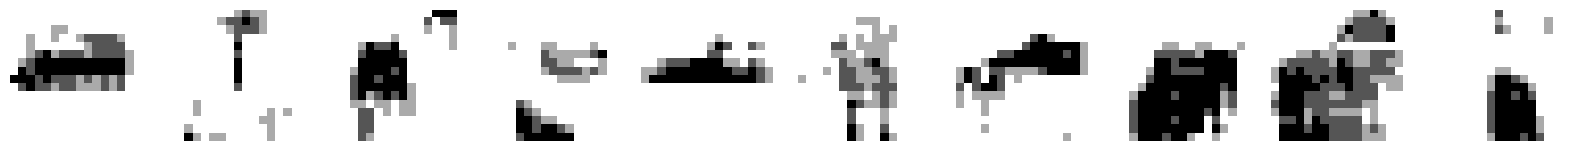

469/469 ━━━━━━━━━━━━━━━━━━━━ 47s 76ms/step - loss: 0.4935
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.4012
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.3873
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 0.3813
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 0.3770


In [12]:
EPOCHS = 5

pixel_cnn.fit(
    input_data,
    output_data,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[tensorboard_callback, img_generator_callback],
)

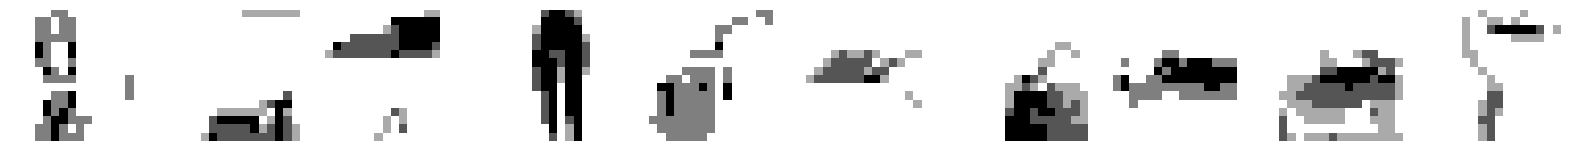

In [13]:
generated_images = img_generator_callback.generate(temperature=1.0)
display(generated_images)

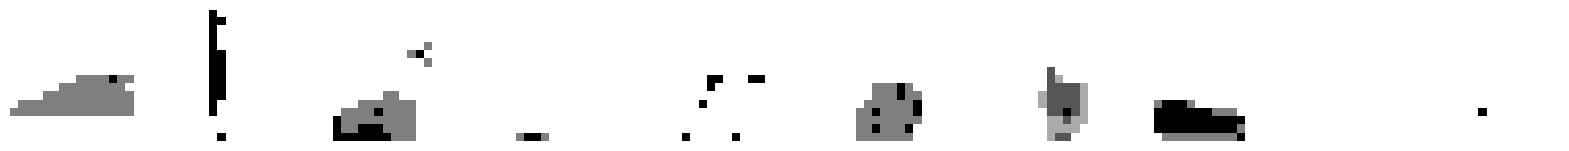

In [14]:
generated_images = img_generator_callback.generate(temperature=0.7)
display(generated_images)

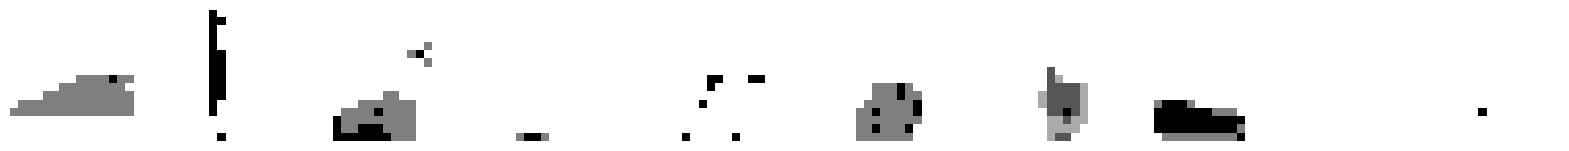

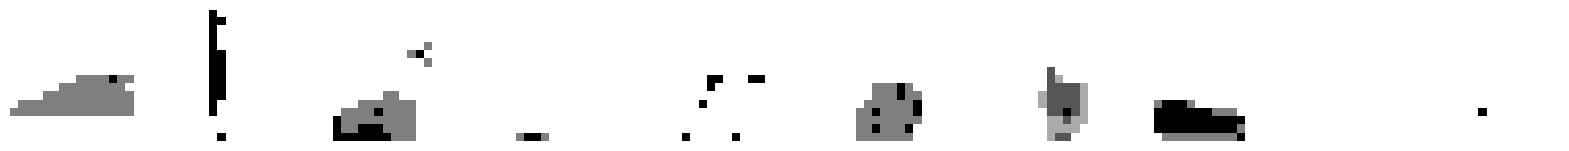

In [15]:
display(generated_images)
display(generated_images)

Temperature changes how PixelCNN generates images: 1.5 gives more random but noisy results, 1.0 gives balanced and natural outputs, and 0.7 produces sharper but less diverse and more repetitive images.